In [3]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np

%matplotlib inline

In [4]:
x,y = make_blobs(n_samples = 1000,centers = 3,n_features = 2,random_state = 23)

In [5]:
x.shape

(1000, 2)

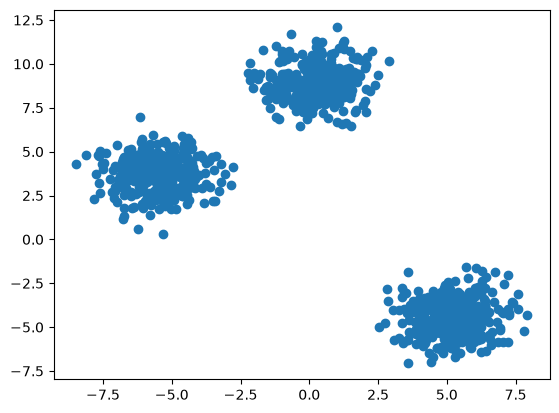

In [6]:
plt.scatter(x[:,0],x[:,1])

In [9]:
from sklearn.model_selection import train_test_split 
x_train,x_test,y_train,y_test = train_test_split(
    x,y,test_size = 0.33,random_state = 42)

In [10]:
from sklearn.cluster import KMeans

In [17]:
# Manual process
# Elbow Method to select the k value

from sklearn.cluster import KMeans

wcss = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=42
    )
    
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)

print(wcss)

[51206.314439777256, 12017.096385908872, 1978.419762413036, 1771.1460915784992, 1518.4894892585348, 1303.349164516084, 1171.3806440012368, 1019.4406251883814, 878.0021319166169, 810.9973234283317]


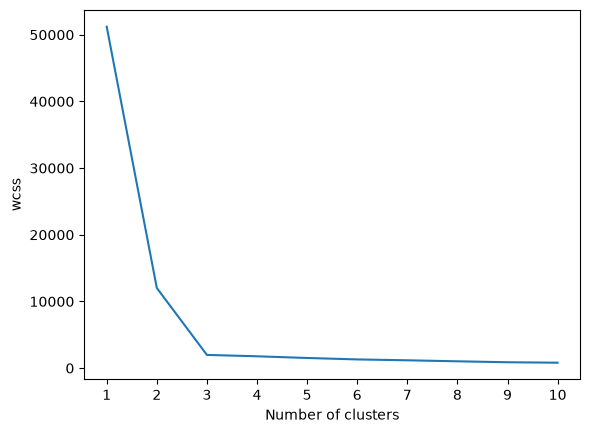

In [19]:
##Plot elbow curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of clusters")
plt.ylabel("wcss")
plt.show()

In [28]:
kmeans = KMeans(n_clusters = 3,init = "k-means++")
y_labels = kmeans.fit_predict(x_train)

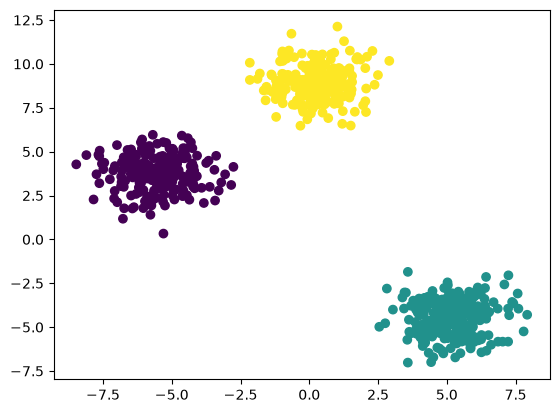

In [31]:
y_test_label = kmeans.predict(x_test)
plt.scatter(x_train[:,0],x_train[:,1],c=y_labels)

In [39]:
##Knee Locator
!pip install kneed
!pip install kneed upgrade pip


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


ERROR: Could not find a version that satisfies the requirement upgrade (from versions: none)
ERROR: No matching distribution found for upgrade


In [44]:
from kneed import KneeLocator

knee = KneeLocator(
    range(1, 11),
    wcss,
    curve='convex',
    direction='decreasing'
)

print("Optimal number of clusters:", knee.elbow)

Optimal number of clusters: 3


In [48]:
##Performance metrics
##Silhouette score
from sklearn.metrics import silhouette_score

In [60]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

silhouette_coefficients = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        random_state=42
    )
    
    kmeans.fit(x_train)
    
    score = silhouette_score(
        x_train,
        kmeans.labels_
    )
    
    silhouette_coefficients.append(score)

silhouette_coefficients

[0.7281443868598331,
 0.8071181203797672,
 0.6357733426488265,
 0.4723297879921876,
 0.33367872107343594,
 0.32758752735600283,
 0.33049705268923796,
 0.3233874690312625,
 0.32630032779404855]

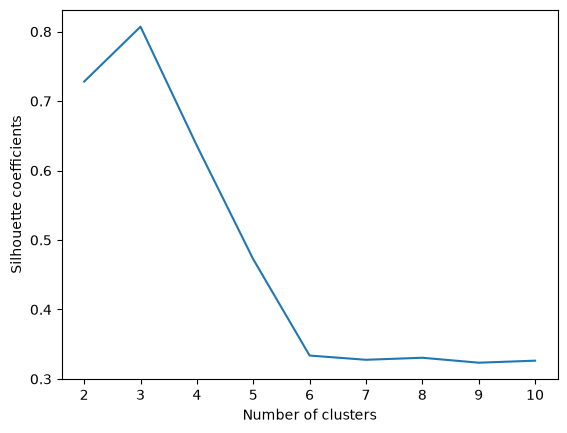

In [61]:
##Plotting silhouette score
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette coefficients")
plt.show()